In [1]:
!git clone https://github.com/bsesic/hebrewmnist.git

Cloning into 'hebrewmnist'...
remote: Enumerating objects: 349, done.
remote: Counting objects: 100% (349/349), done.
remote: Compressing objects: 100% (348/348), done.
remote: Total 349 (delta 1), reused 349 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (349/349), 19.09 MiB | 13.05 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [2]:
import os
import re
import pandas as pd
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import TensorDataset, random_split
from sklearn.preprocessing import LabelEncoder


In [3]:
'''
What need to be changed

Dataset	Size	Mode	Fix needed
Latin	28×28 (CSV) L	Fix rotation/flip
Arabic	32×32	RGB	    Resize + grayscale
Greek	28×28	L	    Nothing
Hindi	32×32	L	    Resize only
Korean	64×64	RGB	    Resize + grayscale
Hebrew	51×104	RGB	    Resize + grayscale
'''

'\nWhat need to be changed\n\nDataset\tSize\tMode\tFix needed\nLatin\t28×28 (CSV) L\tFix rotation/flip\nArabic\t32×32\tRGB\t    Resize + grayscale\nGreek\t28×28\tL\t    Nothing\nHindi\t32×32\tL\t    Resize only\nKorean\t64×64\tRGB\t    Resize + grayscale\nHebrew\t51×104\tRGB\t    Resize + grayscale\n'

# Pre Processing

In [4]:
import torch
import numpy as np
import random

SEED = 42 

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
std_transform = transforms.Compose([
    transforms.Grayscale(1),           
    transforms.Resize((28, 28)),      
    transforms.ToTensor(),             
    transforms.Lambda(lambda x: x.view(-1))  
])

In [6]:
train_df = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-byclass-train.csv', header=None)
test_df  = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-byclass-test.csv',  header=None)

y_train = torch.tensor(train_df.iloc[:, 0].values, dtype=torch.long)
x_train = torch.tensor(train_df.iloc[:, 1:].values, dtype=torch.float32) / 255.0

y_test  = torch.tensor(test_df.iloc[:, 0].values, dtype=torch.long)
x_test  = torch.tensor(test_df.iloc[:, 1:].values, dtype=torch.float32)/255.0


def fix_emnist(x_flat):
    imgs = x_flat.reshape(-1, 28, 28)     
    imgs = torch.rot90(imgs, k=1, dims=[1,2])  
    imgs = torch.flip(imgs, dims=[2])      
    return imgs.reshape(-1, 784)           

x_train = fix_emnist(x_train)
x_test  = fix_emnist(x_test)

latin_train = TensorDataset(x_train,y_train)
latin_test  = TensorDataset(x_test,y_test)

print(f"Latin  -> train: {len(latin_train)} | test: {len(latin_test)} | classes: {y_train.unique().shape[0]}")

Latin  -> train: 697932 | test: 116323 | classes: 62


**ARABIC**

In [7]:
def load_arabic(folder):
    files = sorted(f for f in os.listdir(folder) if f.endswith('.jpg'))
    imgs, raw_labels = [], []
    for f in files:
        img = Image.open(os.path.join(folder, f)).convert('L').resize((28,28))
        imgs.append(np.array(img))
        raw_labels.append(re.sub(r'\d+', '', f.replace('.jpg', '')))
    x = torch.tensor(np.stack(imgs), dtype=torch.float32) / 255.0
    return x.reshape(-1, 784), raw_labels

x_tr, lbl_tr = load_arabic('/kaggle/input/datasets/rashwan/arabic-chars-mnist/train')
x_te, lbl_te = load_arabic('/kaggle/input/datasets/rashwan/arabic-chars-mnist/test')
le_ar        = LabelEncoder().fit(lbl_tr)
arabic_train = TensorDataset(x_tr, torch.tensor(le_ar.transform(lbl_tr), dtype=torch.long))
arabic_test  = TensorDataset(x_te, torch.tensor(le_ar.transform(lbl_te), dtype=torch.long))
print(f"Arabic  -> train: {len(arabic_train)} | test: {len(arabic_test)} | classes: {len(le_ar.classes_)} ")


Arabic  -> train: 13440 | test: 3360 | classes: 28 


**Greek...**

In [8]:
greek_data          = ImageFolder('/kaggle/input/datasets/sayangupta001/mnist-greek-letters/Greek_Letters', std_transform)
tr_n, te_n          = int(0.8*len(greek_data)), len(greek_data)-int(0.8*len(greek_data))
greek_train, greek_test = random_split(greek_data, [tr_n, te_n])
print(f"Greek   -> train: {len(greek_train)} | test: {len(greek_test)} | classes: {len(greek_data.classes)} ")


Greek   -> train: 480 | test: 120 | classes: 24 


**HINDI...**

In [9]:
hindi_train = ImageFolder('/kaggle/input/datasets/berlinsweird/devanagari/Hindi/Train', std_transform)
hindi_test  = ImageFolder('/kaggle/input/datasets/berlinsweird/devanagari/Hindi/Test',  std_transform)
print(f"Hindi   -> train: {len(hindi_train)} | test: {len(hindi_test)} | classes: {len(hindi_train.classes)} ")

Hindi   -> train: 78200 | test: 13800 | classes: 46 


**Korean...**

In [10]:
korean_data          = ImageFolder('/kaggle/input/datasets/jkim289/handwritten-korean-characters/Hangul Database/Hangul Database', std_transform)
tr_n, te_n           = int(0.8*len(korean_data)), len(korean_data)-int(0.8*len(korean_data))
korean_train, korean_test = random_split(korean_data, [tr_n, te_n])
print(f"Korean  -> train: {len(korean_train)} | test: {len(korean_test)} | classes: {len(korean_data.classes)} ")


Korean  -> train: 5120 | test: 1280 | classes: 64 


**HEBREW**

In [11]:
hebrew_data          = ImageFolder('/kaggle/working/hebrewmnist/hebrew_letters', std_transform)
tr_n, te_n           = int(0.8*len(hebrew_data)), len(hebrew_data)-int(0.8*len(hebrew_data))
hebrew_train, hebrew_test = random_split(hebrew_data, [tr_n, te_n])
print(f"Hebrew  -> train: {len(hebrew_train)} | test: {len(hebrew_test)} | classes: {len(hebrew_data.classes)} ")

Hebrew  -> train: 245 | test: 62 | classes: 28 


# DataLoaders

In [12]:
from torch.utils.data import DataLoader
from itertools import cycle

BATCH_SIZE = 32

train_loaders = [
    DataLoader(latin_train,  batch_size=BATCH_SIZE, shuffle=True),
    DataLoader(arabic_train, batch_size=BATCH_SIZE, shuffle=True),
    DataLoader(greek_train,  batch_size=BATCH_SIZE, shuffle=True),
    DataLoader(hindi_train,  batch_size=BATCH_SIZE, shuffle=True),
    DataLoader(korean_train, batch_size=BATCH_SIZE, shuffle=True),
    DataLoader(hebrew_train, batch_size=BATCH_SIZE, shuffle=True),
]

test_loaders = [
    DataLoader(latin_test,  batch_size=256, shuffle=False),
    DataLoader(arabic_test, batch_size=256, shuffle=False),
    DataLoader(greek_test,  batch_size=256, shuffle=False),
    DataLoader(hindi_test,  batch_size=256, shuffle=False),
    DataLoader(korean_test, batch_size=256, shuffle=False),
    DataLoader(hebrew_test, batch_size=256, shuffle=False),
]

#as in our dataset the latin has more batches 
#so others like herbew will finish earlier to avoid that I put inf_iters it will loop
inf_iters = [cycle(loader) for loader in train_loaders]



SCRIPT_NAMES   = ["Latin","Arabic","Greek","Hindi","Korean","Hebrew"]
SCRIPT_CLASSES = [62, 28, 24, 46, 64, 28]

for i, (name, loader) in enumerate(zip(SCRIPT_NAMES, train_loaders)):
    print(f"  m={i} {name}: {len(loader)} batches per epoch")

  m=0 Latin: 21811 batches per epoch
  m=1 Arabic: 420 batches per epoch
  m=2 Greek: 15 batches per epoch
  m=3 Hindi: 2444 batches per epoch
  m=4 Korean: 160 batches per epoch
  m=5 Hebrew: 8 batches per epoch


# Defining Network

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
INPUT_SIZE     = 784
HIDDEN_SIZE    = 128
NUM_G_SETS     = 4
SCRIPT_NAMES   = ["Latin","Arabic","Greek","Hindi","Korean","Hebrew"]
SCRIPT_CLASSES = [62, 28, 24, 46, 64, 28]

B_CONFIGS = torch.tensor([
    [1,1,0,0],   #Latin
    [1,0,1,0],   #Arabic
    [1,0,0,1],   #Greek
    [0,1,1,0],   #Hindi
    [0,1,0,1],   #Korean
    [0,0,1,1],   #Hebrew
], dtype=torch.float32).to(DEVICE)


#G values (compound synapses)
G = nn.Parameter(
    torch.randn(NUM_G_SETS, HIDDEN_SIZE, INPUT_SIZE, device=DEVICE) * 0.01
)

#output heads
head_latin  = nn.Linear(HIDDEN_SIZE, 62).to(DEVICE)
head_arabic = nn.Linear(HIDDEN_SIZE, 28).to(DEVICE)
head_greek  = nn.Linear(HIDDEN_SIZE, 24).to(DEVICE)
head_hindi  = nn.Linear(HIDDEN_SIZE, 46).to(DEVICE)
head_korean = nn.Linear(HIDDEN_SIZE, 64).to(DEVICE)
head_hebrew = nn.Linear(HIDDEN_SIZE, 28).to(DEVICE)

heads = [head_latin, head_arabic, head_greek,
         head_hindi, head_korean, head_hebrew]

def forward(x, m):
    b = B_CONFIGS[m]                         
    W = torch.einsum('n,nhi->hi', b, G)      
    h = F.relu(x @ W.T)                      
    return heads[m](h)                  

#all trainable parameters 
all_params = [G] + [p for head in heads for p in head.parameters()]


# Training Setup

In [14]:
LEARNING_RATE   = 0.001
NUM_EPOCHS      = 100
STEPS_PER_EPOCH = 100
EVAL_EVERY      = 5         

optimizer = torch.optim.Adam(all_params, lr=LEARNING_RATE)


In [15]:
epochs_recorded    = []
train_loss_history = []
test_loss_history  = []
accuracy_history   = {name: [] for name in SCRIPT_NAMES}

print("Training...")

for epoch in range(NUM_EPOCHS):

    total_loss = 0.0

    for step in range(STEPS_PER_EPOCH):
        optimizer.zero_grad()
        step_loss = torch.tensor(0.0, device=DEVICE)

        # one batch from each of the 6 scripts
        for m in range(6):
            x, y = next(inf_iters[m])
            x = x.float().to(DEVICE)
            y = y.to(DEVICE)

            out  = forward(x, m)
            loss = F.cross_entropy(out, y)
            step_loss = step_loss + loss

        # one backprop on the summed loss
        step_loss.backward()
        optimizer.step()

        total_loss += step_loss.item()

    avg_train_loss = total_loss / STEPS_PER_EPOCH


    if (epoch + 1) % EVAL_EVERY == 0:

        epoch_test_loss = 0.0
        accs = []

        with torch.no_grad():
            for m, name in enumerate(SCRIPT_NAMES):
                correct     = 0
                total       = 0
                script_loss = 0.0
                n_batches   = 0

                for x, y in test_loaders[m]:
                    x = x.float().to(DEVICE)
                    y = y.to(DEVICE)

                    out   = forward(x, m)
                    preds = out.argmax(dim=1)

                    correct     += (preds == y).sum().item()
                    total       += y.size(0)
                    script_loss += F.cross_entropy(out, y).item()
                    n_batches   += 1

                # average loss for this script, then add to epoch total
                epoch_test_loss += script_loss / n_batches

                acc = correct / total * 100
                accs.append(acc)
                accuracy_history[name].append(acc)

        epochs_recorded.append(epoch + 1)
        train_loss_history.append(avg_train_loss)
        test_loss_history.append(epoch_test_loss)

        # print
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"train {avg_train_loss:.4f} | test {epoch_test_loss:.4f}")
        acc_str = "  ".join(f"{n[:3]}={a:.1f}%"
                            for n, a in zip(SCRIPT_NAMES, accs))
        print(f"              {acc_str}\n")


print("Training complete")



Training...
Epoch   5/100 | train 8.2610 | test 9.0830
              Lat=66.0%  Ara=34.2%  Gre=73.3%  Hin=65.7%  Kor=36.2%  Heb=74.2%

Epoch  10/100 | train 5.9693 | test 7.3974
              Lat=69.9%  Ara=43.2%  Gre=78.3%  Hin=71.9%  Kor=53.8%  Heb=72.6%

Epoch  15/100 | train 4.9850 | test 6.8394
              Lat=72.2%  Ara=48.9%  Gre=79.2%  Hin=74.3%  Kor=61.4%  Heb=75.8%

Epoch  20/100 | train 4.4756 | test 6.5624
              Lat=72.7%  Ara=53.5%  Gre=78.3%  Hin=78.2%  Kor=63.7%  Heb=74.2%

Epoch  25/100 | train 3.9618 | test 6.2299
              Lat=74.6%  Ara=56.4%  Gre=81.7%  Hin=80.2%  Kor=64.1%  Heb=79.0%

Epoch  30/100 | train 3.7162 | test 5.9824
              Lat=75.6%  Ara=58.4%  Gre=81.7%  Hin=81.5%  Kor=65.0%  Heb=77.4%

Epoch  35/100 | train 3.4947 | test 6.2189
              Lat=76.4%  Ara=59.4%  Gre=81.7%  Hin=82.1%  Kor=67.5%  Heb=77.4%

Epoch  40/100 | train 3.2869 | test 5.9995
              Lat=76.3%  Ara=60.4%  Gre=82.5%  Hin=83.6%  Kor=68.8%  Heb=74.2%

Epoc

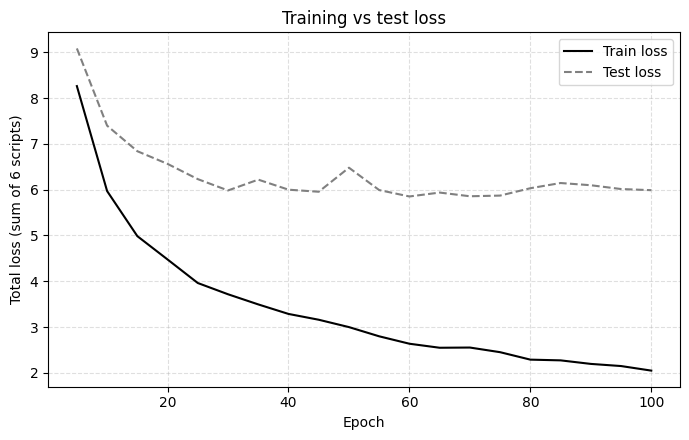

In [16]:

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))
plt.plot(epochs_recorded, train_loss_history,
         color='black', linewidth=1.5, label='Train loss')
plt.plot(epochs_recorded, test_loss_history,
         color='gray',  linewidth=1.5, linestyle='--', label='Test loss')

plt.xlabel('Epoch')
plt.ylabel('Total loss (sum of 6 scripts)')
plt.title('Training vs test loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



